In [1]:
import sys
!{sys.executable} -m pip install matplotlib pandas numpy scikit-learn streamlit

Defaulting to user installation because normal site-packages is not writeable


<div class="alert alert-block alert-info">
    <b>Machine Learning Steps</b> <br>
    1. Data Reading / Data Loading <br>
    2. Data Exploration <br>
    3. Data Pre-Processing <br>
    4. Data Visualization <br>
    5. Train-Test Splitting <br>
    6. Model Application <br>
    7. Model Accuracy <br>
    8. Application Phase <br>
</div>

## **Importing Libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



<div class="alert alert-block alert-success">
    <h1>1. Data Reading / Data Loading</h1>
</div>

In [3]:
exoplanet_data = pd.read_csv('../data/cumulative.csv', sep = ',')
exoplanet_data

,rowid,kepid,kepoi_name,kepler_name,koi_disposition,koi_pdisposition,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,...,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
0,1,10797460,K00752.01,Kepler-227 b,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
1,2,10797460,K00752.02,Kepler-227 c,CONFIRMED,CANDIDATE,0.969,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
2,3,10811496,K00753.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,...,-176.0,4.544,0.044,-0.176,0.868,0.233,-0.078,297.00482,48.134129,15.436
3,4,10848459,K00754.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,...,-174.0,4.564,0.053,-0.168,0.791,0.201,-0.067,285.53461,48.285210,15.597
4,5,10854555,K00755.01,Kepler-664 b,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-211.0,4.438,0.070,-0.210,1.046,0.334,-0.133,288.75488,48.226200,15.509
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9559,9560,10031643,K07984.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,0,0,...,-152.0,4.296,0.231,-0.189,1.088,0.313,-0.228,298.74921,46.973351,14.478
9560,9561,10090151,K07985.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,1,...,-166.0,4.529,0.035,-0.196,0.903,0.237,-0.079,297.18875,47.093819,14.082
9561,9562,10128825,K07986.01,NaN,CANDIDATE,CANDIDATE,0.497,0,0,0,...,-220.0,4.444,0.056,-0.224,1.031,0.341,-0.114,286.50937,47.163219,14.757
9562,9563,10147276,K07987.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.021,0,0,1,...,-236.0,4.447,0.056,-0.224,1.041,0.341,-0.114,294.16489,47.176281,15.385


<div class="alert alert-block alert-success">
    <h1>2. Data Exploration</h1>
</div>

In [4]:
exoplanet_data.head(12)

,rowid,kepid,kepoi_name,kepler_name,koi_disposition,koi_pdisposition,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,...,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
0,1,10797460,K00752.01,Kepler-227 b,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
1,2,10797460,K00752.02,Kepler-227 c,CONFIRMED,CANDIDATE,0.969,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
2,3,10811496,K00753.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,...,-176.0,4.544,0.044,-0.176,0.868,0.233,-0.078,297.00482,48.134129,15.436
3,4,10848459,K00754.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,...,-174.0,4.564,0.053,-0.168,0.791,0.201,-0.067,285.53461,48.285210,15.597
4,5,10854555,K00755.01,Kepler-664 b,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-211.0,4.438,0.070,-0.210,1.046,0.334,-0.133,288.75488,48.226200,15.509
5,6,10872983,K00756.01,Kepler-228 d,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-232.0,4.486,0.054,-0.229,0.972,0.315,-0.105,296.28613,48.224670,15.714
6,7,10872983,K00756.02,Kepler-228 c,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-232.0,4.486,0.054,-0.229,0.972,0.315,-0.105,296.28613,48.224670,15.714
7,8,10872983,K00756.03,Kepler-228 b,CONFIRMED,CANDIDATE,0.992,0,0,0,...,-232.0,4.486,0.054,-0.229,0.972,0.315,-0.105,296.28613,48.224670,15.714
8,9,6721123,K00114.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,1,...,-124.0,3.986,0.182,-0.098,1.958,0.322,-0.483,298.86435,42.151569,12.660
9,10,10910878,K00757.01,Kepler-229 c,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-83.0,4.485,0.083,-0.028,0.848,0.033,-0.072,286.99948,48.375790,15.841


In [5]:
exoplanet_data.tail(100)

,rowid,kepid,kepoi_name,kepler_name,koi_disposition,koi_pdisposition,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,...,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
9464,9465,10585887,K08293.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.190,1,0,0,...,-209.0,4.463,0.070,-0.210,0.970,0.306,-0.123,285.24338,47.812592,14.872
9465,9466,12016243,K07506.01,NaN,CANDIDATE,CANDIDATE,1.000,0,0,0,...,-217.0,4.471,0.056,-0.224,0.999,0.333,-0.111,293.49564,50.480640,15.193
9466,9467,12470530,K07536.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,...,-144.0,4.637,0.060,-0.035,0.621,0.054,-0.054,296.24603,51.369099,15.300
9467,9468,11463950,K07616.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,1,0,0,...,-95.0,3.888,0.182,-0.098,2.531,0.405,-0.607,295.95383,49.374859,13.397
9468,9469,3955867,K07545.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,...,-62.0,2.759,0.128,-0.176,6.447,1.781,-0.822,291.93008,39.072079,13.547
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9559,9560,10031643,K07984.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,0,0,...,-152.0,4.296,0.231,-0.189,1.088,0.313,-0.228,298.74921,46.973351,14.478
9560,9561,10090151,K07985.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,1,...,-166.0,4.529,0.035,-0.196,0.903,0.237,-0.079,297.18875,47.093819,14.082
9561,9562,10128825,K07986.01,NaN,CANDIDATE,CANDIDATE,0.497,0,0,0,...,-220.0,4.444,0.056,-0.224,1.031,0.341,-0.114,286.50937,47.163219,14.757
9562,9563,10147276,K07987.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.021,0,0,1,...,-236.0,4.447,0.056,-0.224,1.041,0.341,-0.114,294.16489,47.176281,15.385


In [6]:
print(f"Number of Rows: {exoplanet_data.shape[0]}, Number of Columns: {exoplanet_data.shape[1]}")

Number of Rows: 9564, Number of Columns: 50


In [7]:
for i in exoplanet_data.columns:
    print(i)

rowid
kepid
kepoi_name
kepler_name
koi_disposition
koi_pdisposition
koi_score
koi_fpflag_nt
koi_fpflag_ss
koi_fpflag_co
koi_fpflag_ec
koi_period
koi_period_err1
koi_period_err2
koi_time0bk
koi_time0bk_err1
koi_time0bk_err2
koi_impact
koi_impact_err1
koi_impact_err2
koi_duration
koi_duration_err1
koi_duration_err2
koi_depth
koi_depth_err1
koi_depth_err2
koi_prad
koi_prad_err1
koi_prad_err2
koi_teq
koi_teq_err1
koi_teq_err2
koi_insol
koi_insol_err1
koi_insol_err2
koi_model_snr
koi_tce_plnt_num
koi_tce_delivname
koi_steff
koi_steff_err1
koi_steff_err2
koi_slogg
koi_slogg_err1
koi_slogg_err2
koi_srad
koi_srad_err1
koi_srad_err2
ra
dec
koi_kepmag


In [8]:
exoplanet_data.count()

rowid                9564
kepid                9564
kepoi_name           9564
kepler_name          2294
koi_disposition      9564
koi_pdisposition     9564
koi_score            8054
koi_fpflag_nt        9564
koi_fpflag_ss        9564
koi_fpflag_co        9564
koi_fpflag_ec        9564
koi_period           9564
koi_period_err1      9110
koi_period_err2      9110
koi_time0bk          9564
koi_time0bk_err1     9110
koi_time0bk_err2     9110
koi_impact           9201
koi_impact_err1      9110
koi_impact_err2      9110
koi_duration         9564
koi_duration_err1    9110
koi_duration_err2    9110
koi_depth            9201
koi_depth_err1       9110
koi_depth_err2       9110
koi_prad             9201
koi_prad_err1        9201
koi_prad_err2        9201
koi_teq              9201
koi_teq_err1            0
koi_teq_err2            0
koi_insol            9243
koi_insol_err1       9243
koi_insol_err2       9243
koi_model_snr        9201
koi_tce_plnt_num     9218
koi_tce_delivname    9218
koi_steff   

In [9]:
exoplanet_data['koi_disposition'].unique()

<ArrowStringArray>
['CONFIRMED', 'FALSE POSITIVE', 'CANDIDATE']
Length: 3, dtype: str

In [10]:
exoplanet_data.nunique()

rowid                9564
kepid                8214
kepoi_name           9564
kepler_name          2294
koi_disposition         3
koi_pdisposition        2
koi_score             650
koi_fpflag_nt           2
koi_fpflag_ss           2
koi_fpflag_co           2
koi_fpflag_ec           2
koi_period           9564
koi_period_err1      7448
koi_period_err2      7448
koi_time0bk          9538
koi_time0bk_err1     2530
koi_time0bk_err2     2530
koi_impact           2406
koi_impact_err1      2217
koi_impact_err2      1884
koi_duration         7834
koi_duration_err1    2264
koi_duration_err2    2264
koi_depth            6947
koi_depth_err1       1428
koi_depth_err2       1428
koi_prad             2988
koi_prad_err1        1787
koi_prad_err2        1561
koi_teq              2511
koi_teq_err1            0
koi_teq_err2            0
koi_insol            7801
koi_insol_err1       7130
koi_insol_err2       6560
koi_model_snr        2740
koi_tce_plnt_num        8
koi_tce_delivname       3
koi_steff   

In [11]:
exoplanet_data.describe()

,rowid,kepid,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,koi_fpflag_ec,koi_period,koi_period_err1,koi_period_err2,...,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
count,9564.000000,9.564000e+03,8054.000000,9564.000000,9564.000000,9564.000000,9564.000000,9564.000000,9110.000000,9110.000000,...,9081.000000,9201.000000,9096.000000,9096.000000,9201.000000,9096.000000,9096.000000,9564.000000,9564.000000,9563.000000
mean,4782.500000,7.690628e+06,0.480829,0.188206,0.231598,0.194898,0.120033,75.671358,0.002148,-0.002148,...,-162.265059,4.310157,0.120738,-0.143161,1.728712,0.362292,-0.394806,292.060163,43.810433,14.264606
std,2761.033321,2.653459e+06,0.476928,0.390897,0.421875,0.396143,0.325018,1334.744046,0.008236,0.008236,...,72.746348,0.432606,0.132837,0.085477,6.127185,0.930870,2.168213,4.766657,3.601243,1.385448
min,1.000000,7.574500e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.241843,0.000000,-0.172500,...,-1762.000000,0.047000,0.000000,-1.207000,0.109000,0.000000,-116.137000,279.852720,36.577381,6.966000
25%,2391.750000,5.556034e+06,0.000000,0.000000,0.000000,0.000000,0.000000,2.733684,0.000005,-0.000276,...,-198.000000,4.218000,0.042000,-0.196000,0.829000,0.129000,-0.250000,288.660770,40.777173,13.440000
50%,4782.500000,7.906892e+06,0.334000,0.000000,0.000000,0.000000,0.000000,9.752831,0.000035,-0.000035,...,-160.000000,4.438000,0.070000,-0.128000,1.000000,0.251000,-0.111000,292.261125,43.677504,14.520000
75%,7173.250000,9.873066e+06,0.998000,0.000000,0.000000,0.000000,0.000000,40.715178,0.000276,-0.000005,...,-114.000000,4.543000,0.149000,-0.088000,1.345000,0.364000,-0.069000,295.859160,46.714611,15.322000
max,9564.000000,1.293514e+07,1.000000,1.000000,1.000000,1.000000,1.000000,129995.778400,0.172500,0.000000,...,0.000000,5.364000,1.472000,0.000000,229.908000,33.091000,0.000000,301.720760,52.336010,20.003000


In [12]:
exoplanet_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 9564 entries, 0 to 9563
Data columns (total 50 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rowid              9564 non-null   int64  
 1   kepid              9564 non-null   int64  
 2   kepoi_name         9564 non-null   str    
 3   kepler_name        2294 non-null   str    
 4   koi_disposition    9564 non-null   str    
 5   koi_pdisposition   9564 non-null   str    
 6   koi_score          8054 non-null   float64
 7   koi_fpflag_nt      9564 non-null   int64  
 8   koi_fpflag_ss      9564 non-null   int64  
 9   koi_fpflag_co      9564 non-null   int64  
 10  koi_fpflag_ec      9564 non-null   int64  
 11  koi_period         9564 non-null   float64
 12  koi_period_err1    9110 non-null   float64
 13  koi_period_err2    9110 non-null   float64
 14  koi_time0bk        9564 non-null   float64
 15  koi_time0bk_err1   9110 non-null   float64
 16  koi_time0bk_err2   9110 non-null   

In [13]:
exoplanet_data.isnull().sum()

rowid                   0
kepid                   0
kepoi_name              0
kepler_name          7270
koi_disposition         0
koi_pdisposition        0
koi_score            1510
koi_fpflag_nt           0
koi_fpflag_ss           0
koi_fpflag_co           0
koi_fpflag_ec           0
koi_period              0
koi_period_err1       454
koi_period_err2       454
koi_time0bk             0
koi_time0bk_err1      454
koi_time0bk_err2      454
koi_impact            363
koi_impact_err1       454
koi_impact_err2       454
koi_duration            0
koi_duration_err1     454
koi_duration_err2     454
koi_depth             363
koi_depth_err1        454
koi_depth_err2        454
koi_prad              363
koi_prad_err1         363
koi_prad_err2         363
koi_teq               363
koi_teq_err1         9564
koi_teq_err2         9564
koi_insol             321
koi_insol_err1        321
koi_insol_err2        321
koi_model_snr         363
koi_tce_plnt_num      346
koi_tce_delivname     346
koi_steff   

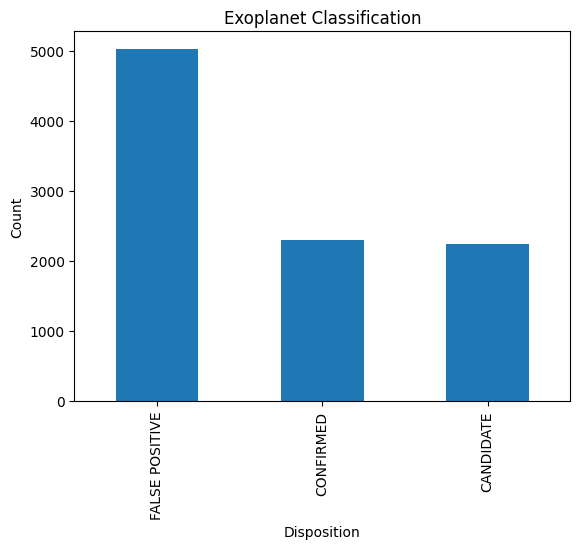

In [14]:
exoplanet_data["koi_disposition"].value_counts().plot(kind="bar")
plt.title("Exoplanet Classification")
plt.xlabel("Disposition")
plt.ylabel("Count")
plt.show()

<div class="alert alert-block alert-success">
    <h1>3. Data Pre-Processing</h1>
</div>

In [15]:
exoplanet_data.shape

(9564, 50)

In [16]:
exoplanet_data["koi_disposition"].value_counts()

koi_disposition
FALSE POSITIVE    5023
CONFIRMED         2293
CANDIDATE         2248
Name: count, dtype: int64

In [17]:
exoplanet_data.isnull().sum().sort_values(ascending=False).head(15)

koi_teq_err2        9564
koi_teq_err1        9564
kepler_name         7270
koi_score           1510
koi_steff_err2       483
koi_srad_err2        468
koi_srad_err1        468
koi_steff_err1       468
koi_slogg_err2       468
koi_slogg_err1       468
koi_time0bk_err1     454
koi_time0bk_err2     454
koi_period_err1      454
koi_period_err2      454
koi_impact_err2      454
dtype: int64

In [18]:
clean_col_used = [
    "koi_period",
    "koi_duration",
    "koi_depth",
    "koi_prad",
    "koi_teq",
    "koi_insol",
    "koi_model_snr",
    "koi_steff",
    "koi_slogg",
    "koi_srad",
    "koi_kepmag",
    "koi_disposition"
]

In [19]:
exoplanet_data = exoplanet_data[clean_col_used]
exoplanet_data

,koi_period,koi_duration,koi_depth,koi_prad,koi_teq,koi_insol,koi_model_snr,koi_steff,koi_slogg,koi_srad,koi_kepmag,koi_disposition
0,9.488036,2.95750,615.8,2.26,793.0,93.59,35.8,5455.0,4.467,0.927,15.347,CONFIRMED
1,54.418383,4.50700,874.8,2.83,443.0,9.11,25.8,5455.0,4.467,0.927,15.347,CONFIRMED
2,19.899140,1.78220,10829.0,14.60,638.0,39.30,76.3,5853.0,4.544,0.868,15.436,FALSE POSITIVE
3,1.736952,2.40641,8079.2,33.46,1395.0,891.96,505.6,5805.0,4.564,0.791,15.597,FALSE POSITIVE
4,2.525592,1.65450,603.3,2.75,1406.0,926.16,40.9,6031.0,4.438,1.046,15.509,CONFIRMED
...,...,...,...,...,...,...,...,...,...,...,...,...
9559,8.589871,4.80600,87.7,1.11,929.0,176.40,8.4,5638.0,4.296,1.088,14.478,FALSE POSITIVE
9560,0.527699,3.22210,1579.2,29.35,2088.0,4500.53,453.3,5638.0,4.529,0.903,14.082,FALSE POSITIVE
9561,1.739849,3.11400,48.5,0.72,1608.0,1585.81,10.6,6119.0,4.444,1.031,14.757,CANDIDATE
9562,0.681402,0.86500,103.6,1.07,2218.0,5713.41,12.3,6173.0,4.447,1.041,15.385,FALSE POSITIVE


In [20]:
exoplanet_data = exoplanet_data.dropna()
exoplanet_data

,koi_period,koi_duration,koi_depth,koi_prad,koi_teq,koi_insol,koi_model_snr,koi_steff,koi_slogg,koi_srad,koi_kepmag,koi_disposition
0,9.488036,2.95750,615.8,2.26,793.0,93.59,35.8,5455.0,4.467,0.927,15.347,CONFIRMED
1,54.418383,4.50700,874.8,2.83,443.0,9.11,25.8,5455.0,4.467,0.927,15.347,CONFIRMED
2,19.899140,1.78220,10829.0,14.60,638.0,39.30,76.3,5853.0,4.544,0.868,15.436,FALSE POSITIVE
3,1.736952,2.40641,8079.2,33.46,1395.0,891.96,505.6,5805.0,4.564,0.791,15.597,FALSE POSITIVE
4,2.525592,1.65450,603.3,2.75,1406.0,926.16,40.9,6031.0,4.438,1.046,15.509,CONFIRMED
...,...,...,...,...,...,...,...,...,...,...,...,...
9559,8.589871,4.80600,87.7,1.11,929.0,176.40,8.4,5638.0,4.296,1.088,14.478,FALSE POSITIVE
9560,0.527699,3.22210,1579.2,29.35,2088.0,4500.53,453.3,5638.0,4.529,0.903,14.082,FALSE POSITIVE
9561,1.739849,3.11400,48.5,0.72,1608.0,1585.81,10.6,6119.0,4.444,1.031,14.757,CANDIDATE
9562,0.681402,0.86500,103.6,1.07,2218.0,5713.41,12.3,6173.0,4.447,1.041,15.385,FALSE POSITIVE


In [21]:
exoplanet_data = exoplanet_data[exoplanet_data["koi_disposition"].isin(["CONFIRMED", "FALSE POSITIVE"])]

In [22]:
exoplanet_data["koi_disposition"] = exoplanet_data["koi_disposition"].map({"CONFIRMED": 1,"FALSE POSITIVE": 0})
exoplanet_data

,koi_period,koi_duration,koi_depth,koi_prad,koi_teq,koi_insol,koi_model_snr,koi_steff,koi_slogg,koi_srad,koi_kepmag,koi_disposition
0,9.488036,2.95750,615.8,2.26,793.0,93.59,35.8,5455.0,4.467,0.927,15.347,1
1,54.418383,4.50700,874.8,2.83,443.0,9.11,25.8,5455.0,4.467,0.927,15.347,1
2,19.899140,1.78220,10829.0,14.60,638.0,39.30,76.3,5853.0,4.544,0.868,15.436,0
3,1.736952,2.40641,8079.2,33.46,1395.0,891.96,505.6,5805.0,4.564,0.791,15.597,0
4,2.525592,1.65450,603.3,2.75,1406.0,926.16,40.9,6031.0,4.438,1.046,15.509,1
...,...,...,...,...,...,...,...,...,...,...,...,...
9556,23.627035,11.48100,8433.0,21.71,560.0,23.17,78.4,5305.0,4.477,0.857,16.375,0
9559,8.589871,4.80600,87.7,1.11,929.0,176.40,8.4,5638.0,4.296,1.088,14.478,0
9560,0.527699,3.22210,1579.2,29.35,2088.0,4500.53,453.3,5638.0,4.529,0.903,14.082,0
9562,0.681402,0.86500,103.6,1.07,2218.0,5713.41,12.3,6173.0,4.447,1.041,15.385,0


In [23]:
exoplanet_data.info()

<class 'pandas.DataFrame'>
Index: 7015 entries, 0 to 9563
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   koi_period       7015 non-null   float64
 1   koi_duration     7015 non-null   float64
 2   koi_depth        7015 non-null   float64
 3   koi_prad         7015 non-null   float64
 4   koi_teq          7015 non-null   float64
 5   koi_insol        7015 non-null   float64
 6   koi_model_snr    7015 non-null   float64
 7   koi_steff        7015 non-null   float64
 8   koi_slogg        7015 non-null   float64
 9   koi_srad         7015 non-null   float64
 10  koi_kepmag       7015 non-null   float64
 11  koi_disposition  7015 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 712.5 KB


In [24]:
exoplanet_data.to_csv('../data/cleaned_exoplanet_data.csv', index=False, header=True)

<div class="alert alert-block alert-success">
    <h1>4. Data Visualization</h1>
</div>

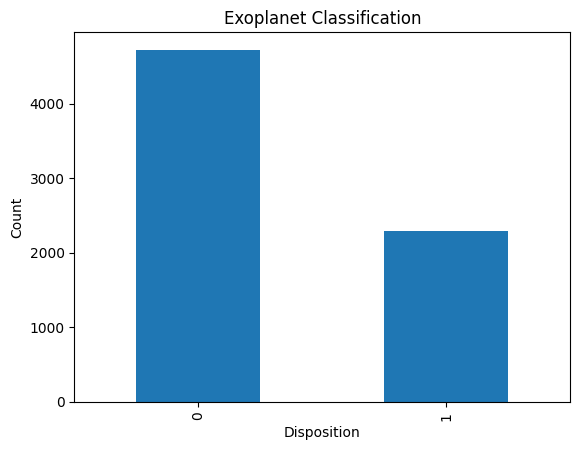

In [25]:
exoplanet_data["koi_disposition"].value_counts().plot(kind="bar")
plt.title("Exoplanet Classification")
plt.xlabel("Disposition")
plt.ylabel("Count")
plt.show()

<div class="alert alert-block alert-success">
    <h1>5. Train-Test Splitting</h1>
</div>

In [26]:
exoplanet_data = pd.read_csv('../data/cleaned_exoplanet_data.csv', sep = ',')

In [27]:
X = exoplanet_data.drop('koi_disposition', axis=1)
y = exoplanet_data['koi_disposition']

In [28]:
X_train, X_test, y_train, y_test = train_test_split( X, y,test_size=0.2, random_state=42, stratify=y)

print(f'Training Splition: {X_train.shape}')
print(f'Testing Splition: {X_test.shape}')

Training Splition: (5612, 11)
Testing Splition: (1403, 11)


<div class="alert alert-block alert-success">
    <h1>6. Model Application</h1>
</div>

## **Binominal Logistic Regression**

In [29]:
bin_log_regg = LogisticRegression(max_iter=1000)
bin_log_regg.fit(X_train, y_train)

C:\Users\alibh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [30]:
y_pred = bin_log_regg.predict(X_test)
y_pred

array([0, 1, 0, ..., 0, 0, 1], shape=(1403,))

## **Random Forest Classifier**

In [31]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [32]:
rf_pred = rf_model.predict(X_test)
rf_pred

array([0, 1, 1, ..., 0, 0, 1], shape=(1403,))

<div class="alert alert-block alert-success">
    <h1>7. Model Accuracy</h1>
</div>

## **Binominal Logistic Regression Accuracy**

In [33]:
acc = accuracy_score(y_test, y_pred)*100
print(f"Binominal Logistic Regression model accuracy: {acc:.2f}%")

Binominal Logistic Regression model accuracy: 84.39%


In [34]:
print(f'Binominal Logistic Regression Model Classification Report')
print(classification_report(y_test,y_pred))

Binominal Logistic Regression Model Classification Report
              precision    recall  f1-score   support

           0       0.91      0.85      0.88       945
           1       0.73      0.83      0.78       458

    accuracy                           0.84      1403
   macro avg       0.82      0.84      0.83      1403
weighted avg       0.85      0.84      0.85      1403



In [35]:
print(f'Binominal Logistic Regression Model Confusion Matrix')
print(confusion_matrix(y_test,y_pred))

Binominal Logistic Regression Model Confusion Matrix
[[802 143]
 [ 76 382]]


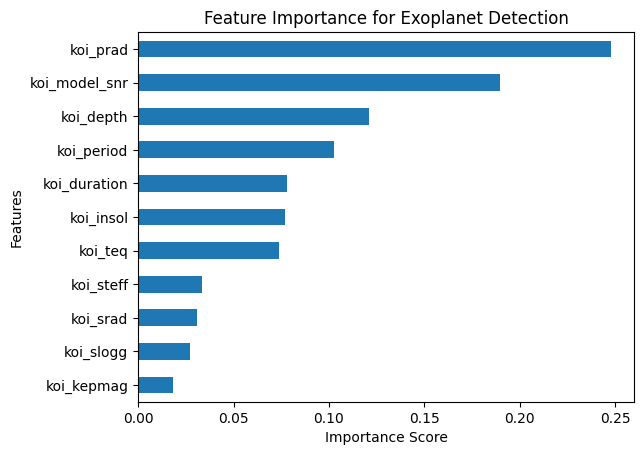

In [36]:
importance = pd.Series(rf_model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=True)

importance.plot(kind="barh")
plt.title("Feature Importance for Exoplanet Detection")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

## **Random Forest Accuracy**

In [37]:
rf_accuracy = accuracy_score(y_test, rf_pred)*100

print(f'Random Forest Accuracy: {rf_accuracy:.2f}%')

Random Forest Accuracy: 90.45%


In [38]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.96      0.90      0.93       945
           1       0.81      0.92      0.86       458

    accuracy                           0.90      1403
   macro avg       0.89      0.91      0.89      1403
weighted avg       0.91      0.90      0.91      1403



In [39]:
print(confusion_matrix(y_test, rf_pred))

[[849  96]
 [ 38 420]]


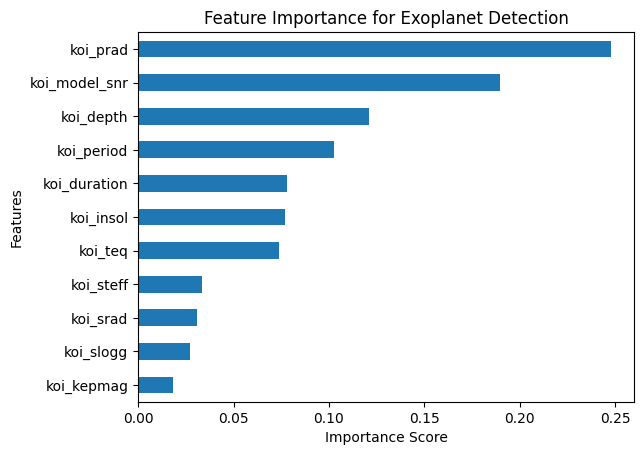

In [40]:
importance = pd.Series(rf_model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=True)

importance.plot(kind="barh")
plt.title("Feature Importance for Exoplanet Detection")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

## **Saving Trained Random Forest Classifier Model**

In [41]:
# Saving Trained Model
pickle.dump(rf_model, open('../models/rf_model.pkl', 'wb'))

## **Loading Trained Random Forest Classifier Model**

In [42]:
# Load Saved Model
rf_model = pickle.load(open('../models/rf_model.pkl', 'rb'))

## **Again Testing The Accuracy Of Random Forest Classifier Model**

In [43]:
rf_accuracy = accuracy_score(y_test, rf_pred)*100

print(f'Random Forest Accuracy: {rf_accuracy:.2f}%')

Random Forest Accuracy: 90.45%


<div class="alert alert-block alert-success">
    <h1>8. Application Phase</h1>
</div>

In [44]:
import pandas as pd
import numpy as np
import pickle

# Load model
model = pickle.load(open('../models/rf_model.pkl', 'rb'))

# Manual Encoding
label_map = {
    "FALSE POSITIVE": 0,
    "CONFIRMED": 1
}

# User Inputs
print("Enter Exoplanet Data:")

user_input = {
    "koi_period":    float(input("Orbital Period: ")),
    "koi_duration":  float(input("Transit Duration: ")),
    "koi_depth":     float(input("Transit Depth: ")),
    "koi_prad":      float(input("Planet Radius: ")),
    "koi_teq":       float(input("Equilibrium Temp: ")),
    "koi_insol":     float(input("Insolation Flux: ")),
    "koi_model_snr": float(input("Signal-to-Noise Ratio: ")),
    "koi_steff":     float(input("Stellar Temp: ")),
    "koi_slogg":     float(input("Surface Gravity: ")),
    "koi_srad":      float(input("Stellar Radius: ")),
    "koi_kepmag":    float(input("Kepler Magnitude: "))
}

# features
features = [
    "koi_period",
    "koi_duration",
    "koi_depth",
    "koi_prad",
    "koi_teq",
    "koi_insol",
    "koi_model_snr",
    "koi_steff",
    "koi_slogg",
    "koi_srad",
    "koi_kepmag"
]

X = np.array([[user_input[cols] for cols in features]])

# Predict
predict = model.predict(X)

# Decode output manually
reverse_map = {0: "FALSE POSITIVE", 1: "CONFIRMED"}

print("Prediction:", reverse_map[predict[0]])

Enter Exoplanet Data:


Prediction: FALSE POSITIVE


C:\Users\alibh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
